# Day 08. Exercise 05
# Clustering

## 0. Imports

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster import hierarchy
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

## 1. Preprocessing

In [45]:
df = pd.read_csv('../data/regression.csv', usecols=['uid','num_commits','AVG(diff)'])
X = df[['num_commits', 'AVG(diff)']]

## 2. KMeans

Silhouette_score KMeans: 0.4454402135233297


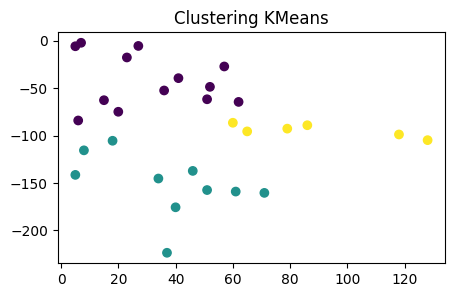

In [46]:
kmeans = KMeans(n_clusters=3, random_state=21).fit(X)
labels = kmeans.labels_
print(f'Silhouette_score KMeans: {silhouette_score(X, kmeans.fit_predict(X))}')

plt.figure(figsize=(5, 3))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=labels, cmap='viridis')
plt.title('Clustering KMeans')
plt.show()

other coefficients

silhouette score for 2 cluster: 0.4194920562377423
silhouette score for 4 cluster: 0.41503879936268956
silhouette score for 6 cluster: 0.3954350435152892
silhouette score for 8 cluster: 0.48638087320227846


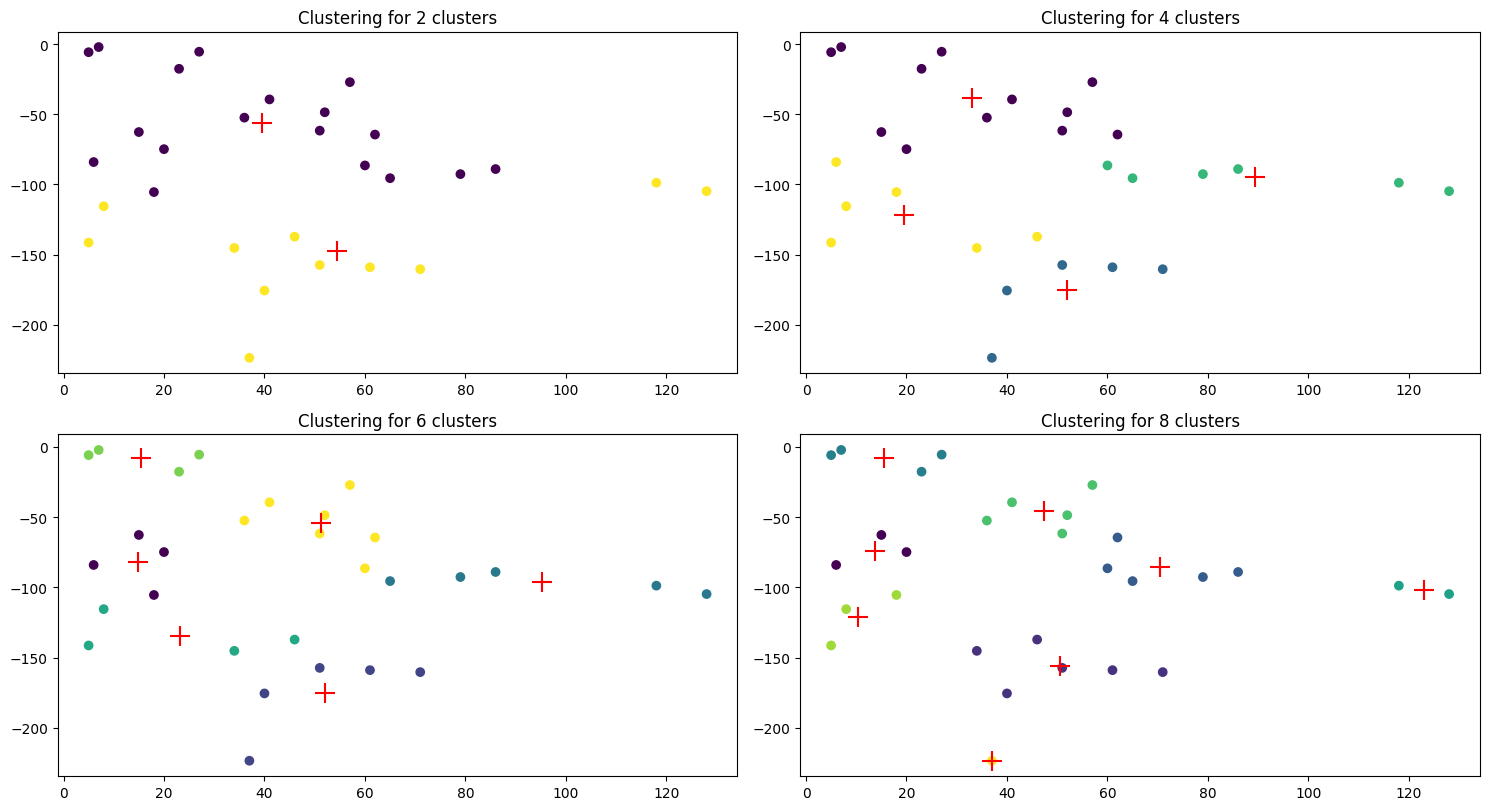

In [47]:
plt.figure(figsize=(15, 12))

for i, cluster in enumerate(range(2,10,2)):
    kmeans = KMeans(n_clusters=cluster, random_state=21).fit(X)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    ax = plt.subplot(3, 2, i+1)
    scatter = ax.scatter(df['num_commits'], df['AVG(diff)'], c=labels, cmap='viridis')
    scatter = ax.scatter(centers[:, 0], centers[:, 1], marker='+', s=200, c='red', label='Centroids')

    plt.title(f'Clustering for {cluster} clusters')
    print(f'silhouette score for {cluster} cluster: {silhouette_score(X, kmeans.fit_predict(X))}')

plt.tight_layout()
plt.show()

## 3. DBSCAN

Silhouette_score DBSCAN: 0.38339641455696616


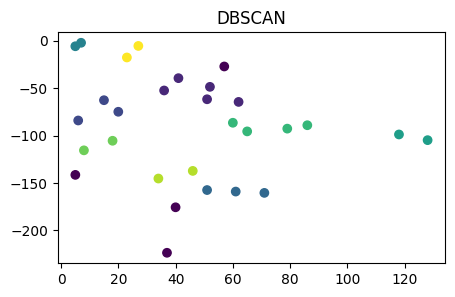

In [48]:
dbscan = DBSCAN(eps=20, min_samples=2).fit(X)
labels = dbscan.labels_

plt.figure(figsize=(5,3))
plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels)
plt.title('DBSCAN')

print(f'Silhouette_score DBSCAN: {silhouette_score(X, dbscan.fit_predict(X))}')

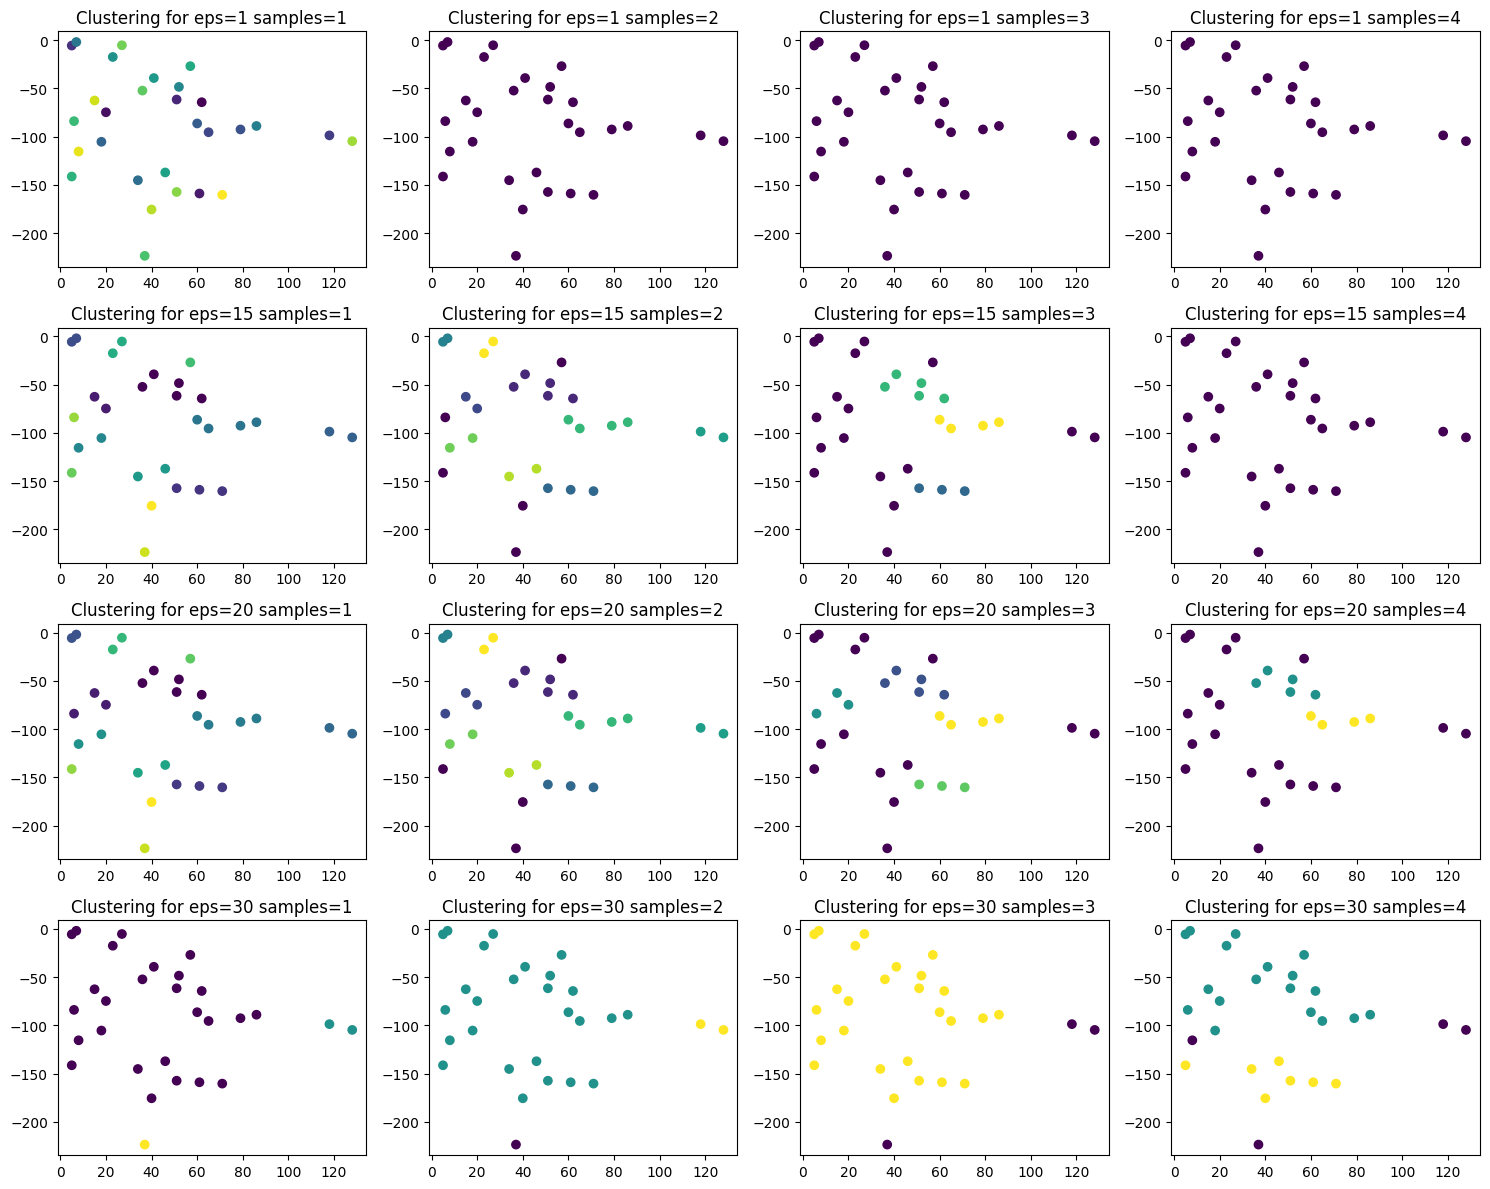

In [ ]:
eps = [1, 15, 20, 30]
samples =[1, 2, 3, 4]

plt.figure(figsize=(15, 12))

for i, i_eps in enumerate(eps, 1):
    for j, j_samples in enumerate(samples, 1):

        subplot_idx = (i-1)*len(samples) + j

        dbscan = DBSCAN(eps=i_eps, min_samples=j_samples).fit(X)
        labels = dbscan.labels_
        
        ax = plt.subplot(len(eps), len(samples), subplot_idx)
        scatter = ax.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='viridis')
        plt.title(f'Clustering for eps={i_eps} samples={j_samples}')

plt.tight_layout()
plt.show()

## 4. Hierarchical (AgglomerativeClustering)

In [63]:
agg_clustering = AgglomerativeClustering(n_clusters=5).fit(X)
labels = agg_clustering.labels_
print(f'Silhouette_score Agglomerative Clustering: {silhouette_score(X, agg_clustering.fit_predict(X))}')

Silhouette_score Agglomerative Clustering: 0.46383015199381467


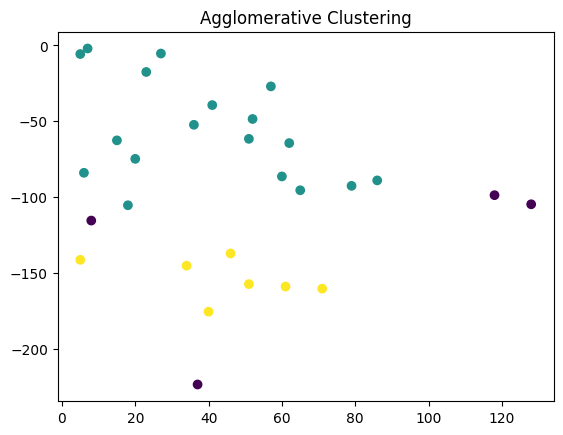

In [61]:
plt.scatter(df['num_commits'], df['AVG(diff)'], c=labels)
plt.title('Agglomerative Clustering')
plt.show()

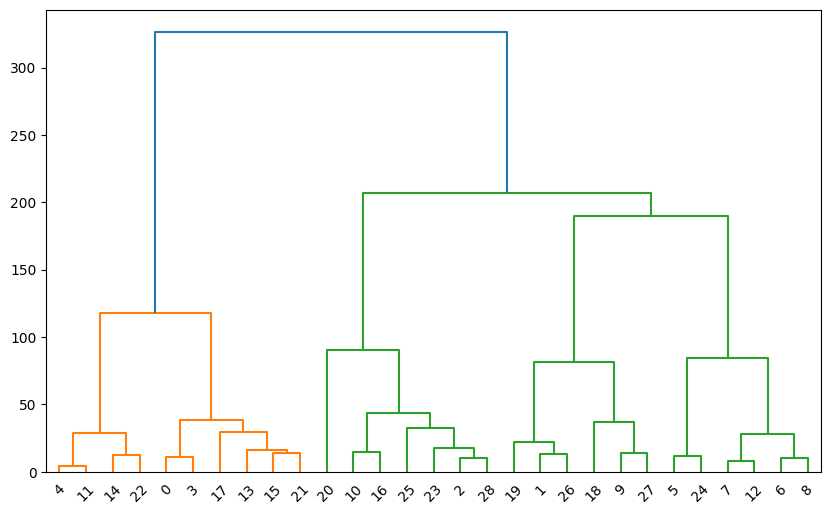

In [52]:
plt.figure(figsize=(10, 6))
Z = hierarchy.linkage(X, method='ward')
dn = hierarchy.dendrogram(Z)

## 5. Function

In [54]:
def clustering_optimization(model, param, param_name, param_range, X=X):
    res=[]
    best = 0
    best_value = None
    label = None
    for value in param_range:
        curr_param = param.copy()
        curr_param[param_name] = value
        curr_model = model(**curr_param)

        curr_model.fit(X)

        labels = curr_model.fit_predict(X)
        
        n_clusters = len(np.unique(labels))
        if n_clusters == 1 or n_clusters >= len(X): res.append(-1)
        else:
            score = silhouette_score(X, labels)
            res.append(score)
        if score > best:
            best = score
            best_value = value
            label = labels

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20,8))
    
    ax1.plot(param_range, res)
    ax1.set_title('Depending silhouette of the parameter')
    ax1.set_ylabel('Score')
    ax1.set_xlabel('Value')


    ax2.scatter(X['num_commits'], X['AVG(diff)'], c=label)
    ax2.set_title(f'Model with best {param_name} value == {best_value}')

KMeans

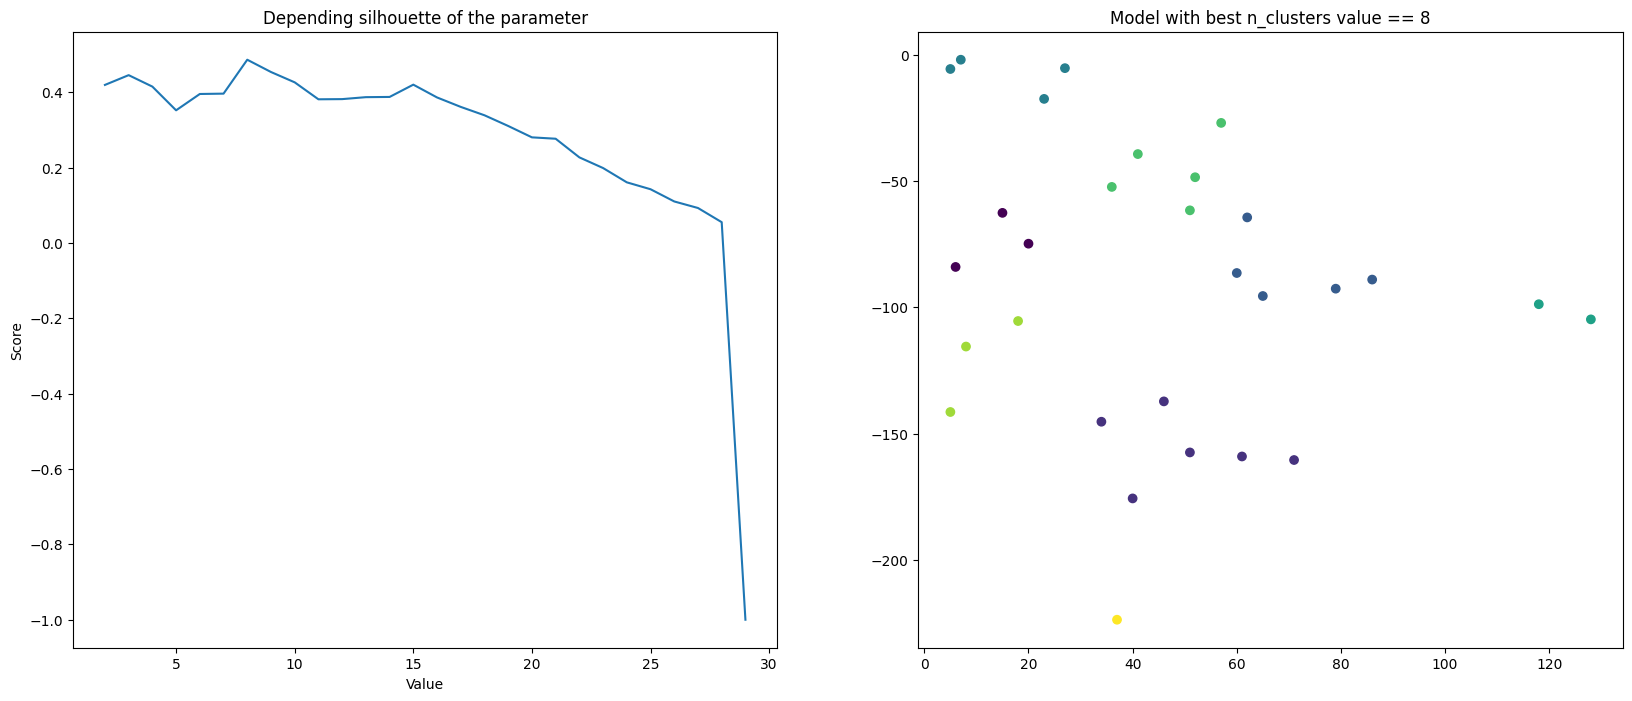

In [55]:
clustering_optimization(KMeans, {'random_state': 21}, 'n_clusters', range(2,30))

DBSCAN

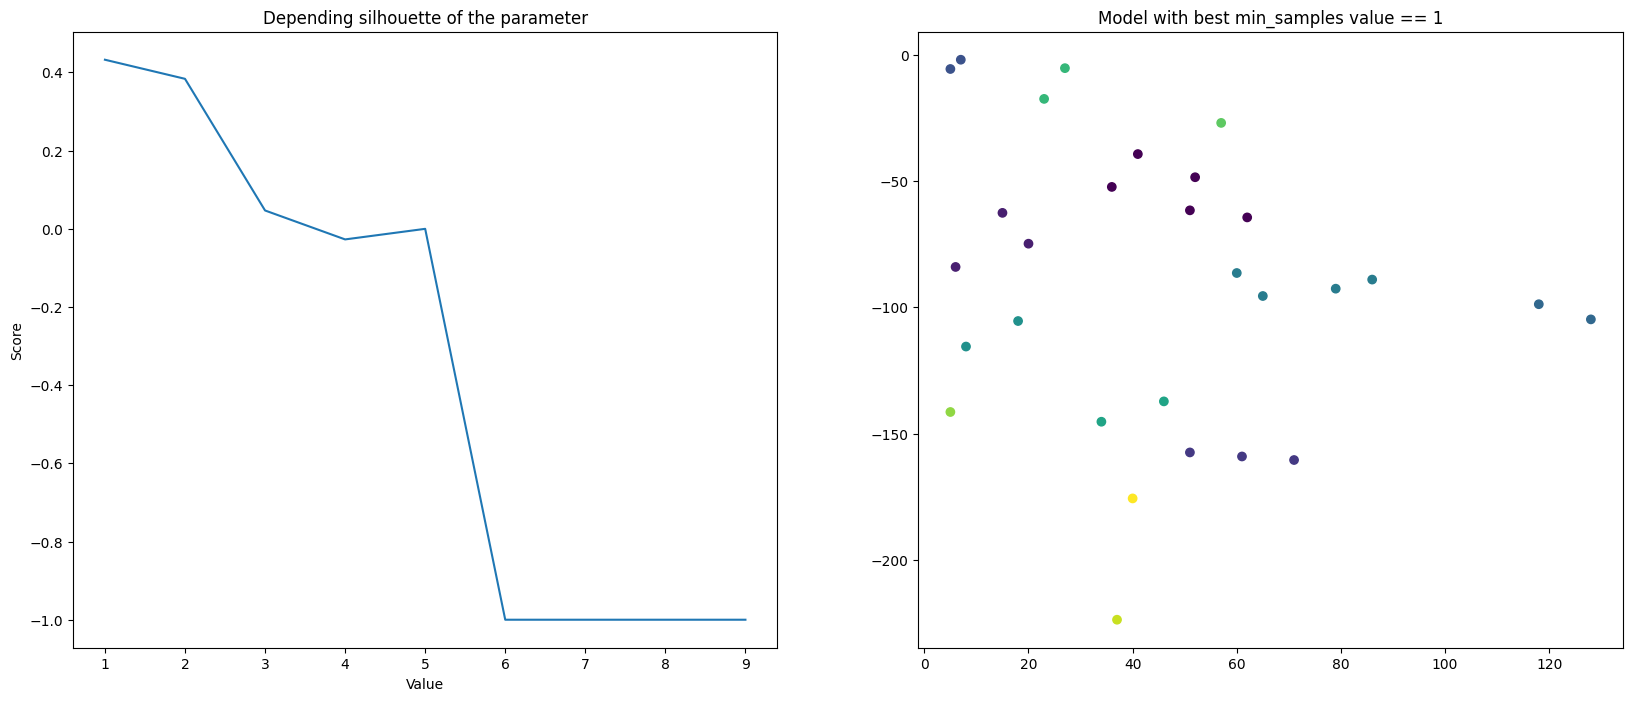

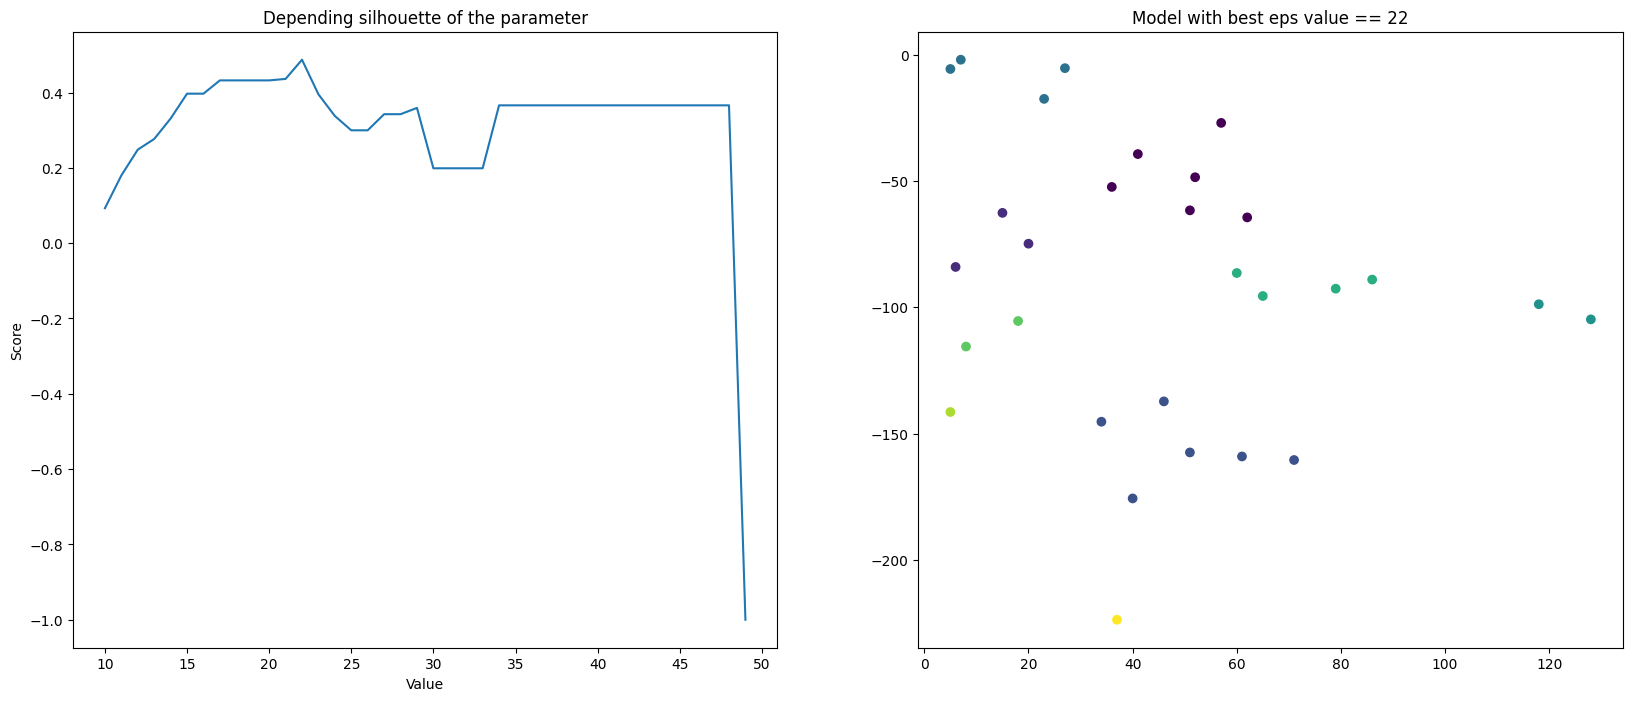

In [56]:
clustering_optimization(DBSCAN, {'eps':20}, 'min_samples', range(1,10))
clustering_optimization(DBSCAN, {'min_samples':1}, 'eps', range(10, 50))

AgglomerativeClustering

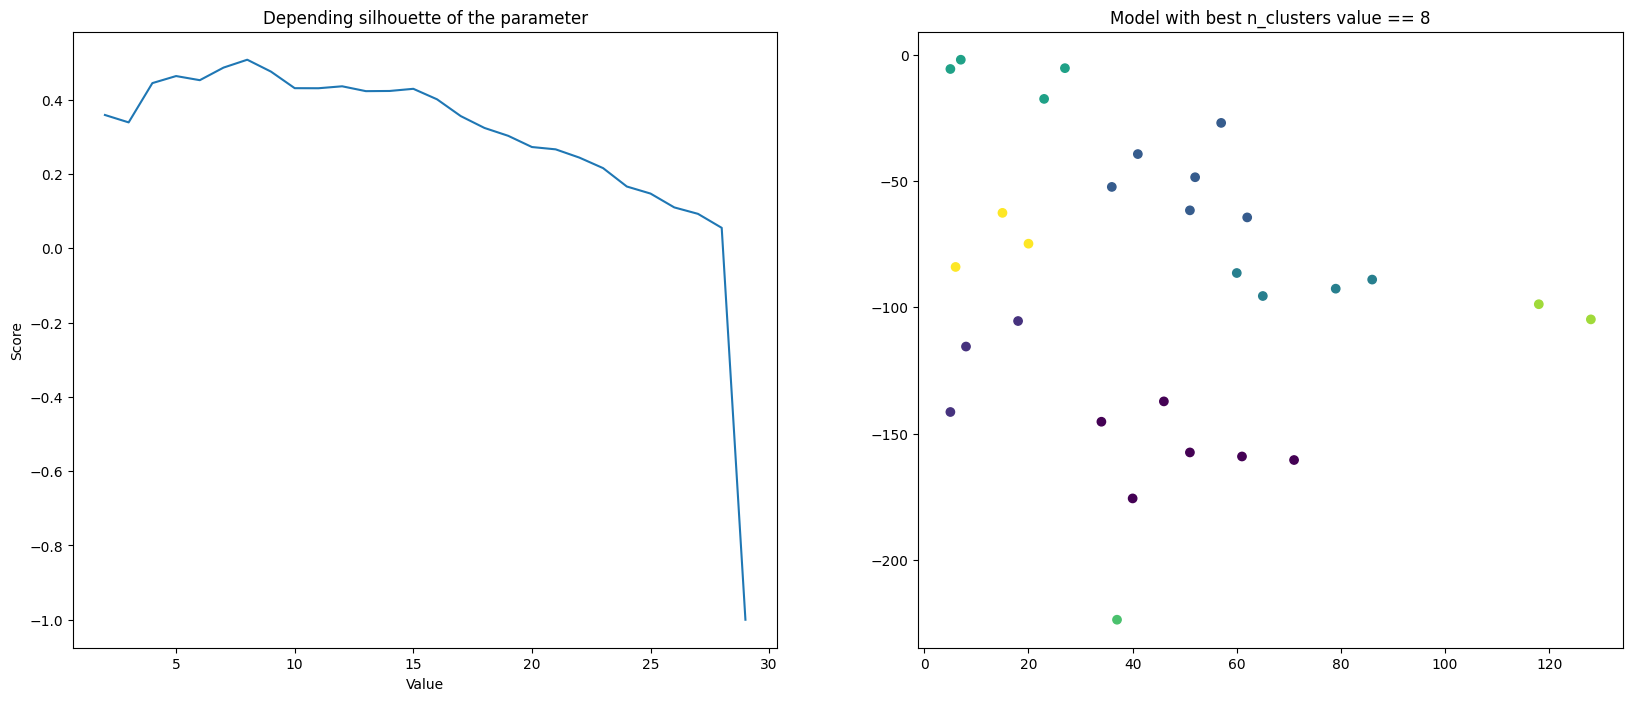

In [57]:
clustering_optimization(AgglomerativeClustering, {}, 'n_clusters', range(2, 30))